In [1]:
# ── CELL 1: Import Libraries ──────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder

import warnings
warnings.filterwarnings('ignore')

print('✅ All libraries imported!')

✅ All libraries imported!


In [2]:
# ── CELL 2: Load Dataset ──────────────────────────────
# 👇 Make sure car data.csv is in the same folder as this notebook
df = pd.read_csv('car data.csv')

print('✅ Dataset loaded!')
print(f'Shape: {df.shape}  ← (rows, columns)')
print(f'Columns: {list(df.columns)}')
df.head(10)

✅ Dataset loaded!
Shape: (301, 9)  ← (rows, columns)
Columns: ['Car_Name', 'Year', 'Selling_Price', 'Present_Price', 'Kms_Driven', 'Fuel_Type', 'Seller_Type', 'Transmission', 'Owner']


,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0
5,vitara brezza,2018,9.25,9.83,2071,Diesel,Dealer,Manual,0
6,ciaz,2015,6.75,8.12,18796,Petrol,Dealer,Manual,0
7,s cross,2015,6.50,8.61,33429,Diesel,Dealer,Manual,0
8,ciaz,2016,8.75,8.89,20273,Diesel,Dealer,Manual,0
9,ciaz,2015,7.45,8.92,42367,Diesel,Dealer,Manual,0


In [8]:
# ── CELL 3: Explore the Data ──────────────────────────
print('=== DATASET INFO ===')
print(df.info())
print('\n=== STATISTICS ===')
print(df.describe().round(2))
print('\n=== MISSING VALUES ===')
print(df.isnull().sum())
print('\n=== UNIQUE VALUES PER COLUMN ===')
for col in df.columns:
    print(f'  {col}: {df[col].nunique()} unique values')

# ── CELL 3 TEMP: Check exact column names ──
print(df.columns.tolist())
print(df.head(2))

=== DATASET INFO ===
<class 'pandas.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Selling_Price  301 non-null    float64
 1   Present_Price  301 non-null    float64
 2   Kms_Driven     301 non-null    int64  
 3   Fuel_Type      301 non-null    int64  
 4   Seller_Type    301 non-null    str    
 5   Transmission   301 non-null    str    
 6   Owner          301 non-null    int64  
 7   Car_Age        301 non-null    int64  
dtypes: float64(2), int64(4), str(2)
memory usage: 18.9 KB
None

=== STATISTICS ===
       Selling_Price  Present_Price  Kms_Driven  Fuel_Type   Owner  Car_Age
count         301.00         301.00      301.00     301.00  301.00   301.00
mean            4.66           7.63    36947.21       1.79    0.04    12.37
std             5.08           8.64    38886.88       0.43    0.25     2.89
min             0.10           0.32      500.00       0.00

In [4]:
# ── CELL 4: Feature Engineering ───────────────────────
# The dataset has a 'Year' column (year car was bought)
# We convert it to 'Car_Age' = how old the car is
# Because age matters more than the year itself!

from datetime import datetime
current_year = datetime.now().year

df['Car_Age'] = current_year - df['Year']

# Drop columns we don't need for prediction
df = df.drop(['Car_Name', 'Year'], axis=1)

print('✅ Feature engineering done!')
print(f'New column added: Car_Age')
print(f'Dropped: Car_Name, Year')
print(f'\nFinal columns: {list(df.columns)}')
df.head()

✅ Feature engineering done!
New column added: Car_Age
Dropped: Car_Name, Year

Final columns: ['Selling_Price', 'Present_Price', 'Kms_Driven', 'Fuel_Type', 'Seller_Type', 'Transmission', 'Owner', 'Car_Age']


,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner,Car_Age
0,3.35,5.59,27000,Petrol,Dealer,Manual,0,12
1,4.75,9.54,43000,Diesel,Dealer,Manual,0,13
2,7.25,9.85,6900,Petrol,Dealer,Manual,0,9
3,2.85,4.15,5200,Petrol,Dealer,Manual,0,15
4,4.60,6.87,42450,Diesel,Dealer,Manual,0,12


In [9]:
# ── CELL 5 FIXED: Encode Categorical Columns ──────────
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

cat_cols = ['Seller_Type', 'Transmission']

for col in cat_cols:
    df[col] = le.fit_transform(df[col])
    print(f'  {col}: converted to numbers')

print('\n✅ All text columns converted to numbers!')
print('\nEncoded dataset preview:')
df.head()

  Seller_Type: converted to numbers
  Transmission: converted to numbers

✅ All text columns converted to numbers!

Encoded dataset preview:


,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner,Car_Age
0,3.35,5.59,27000,2,0,1,0,12
1,4.75,9.54,43000,1,0,1,0,13
2,7.25,9.85,6900,2,0,1,0,9
3,2.85,4.15,5200,2,0,1,0,15
4,4.60,6.87,42450,1,0,1,0,12


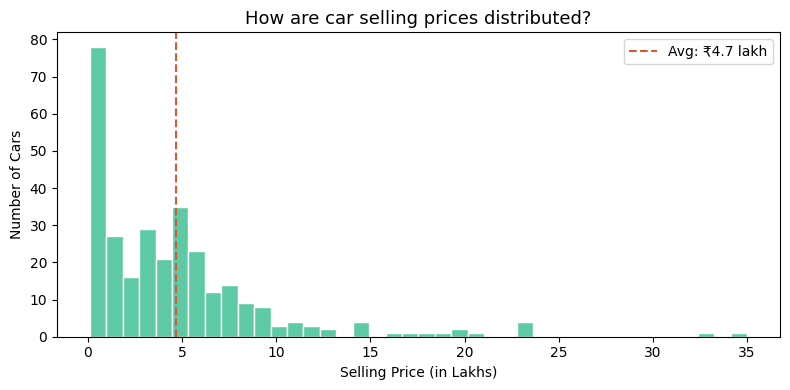

Cheapest car : ₹0.1 lakh
Most expensive: ₹35.0 lakh
Average price : ₹4.66 lakh


In [10]:
# ── CELL 6: Chart 1 — Selling Price Distribution ──────
plt.figure(figsize=(8, 4))
plt.hist(df['Selling_Price'], bins=40,
         color='#5DCAA5', edgecolor='white')
plt.axvline(df['Selling_Price'].mean(),
            color='#D85A30', linestyle='--',
            label=f"Avg: ₹{df['Selling_Price'].mean():.1f} lakh")
plt.title('How are car selling prices distributed?', fontsize=13)
plt.xlabel('Selling Price (in Lakhs)')
plt.ylabel('Number of Cars')
plt.legend()
plt.tight_layout()
plt.show()
print(f"Cheapest car : ₹{df['Selling_Price'].min()} lakh")
print(f"Most expensive: ₹{df['Selling_Price'].max()} lakh")
print(f"Average price : ₹{df['Selling_Price'].mean():.2f} lakh")

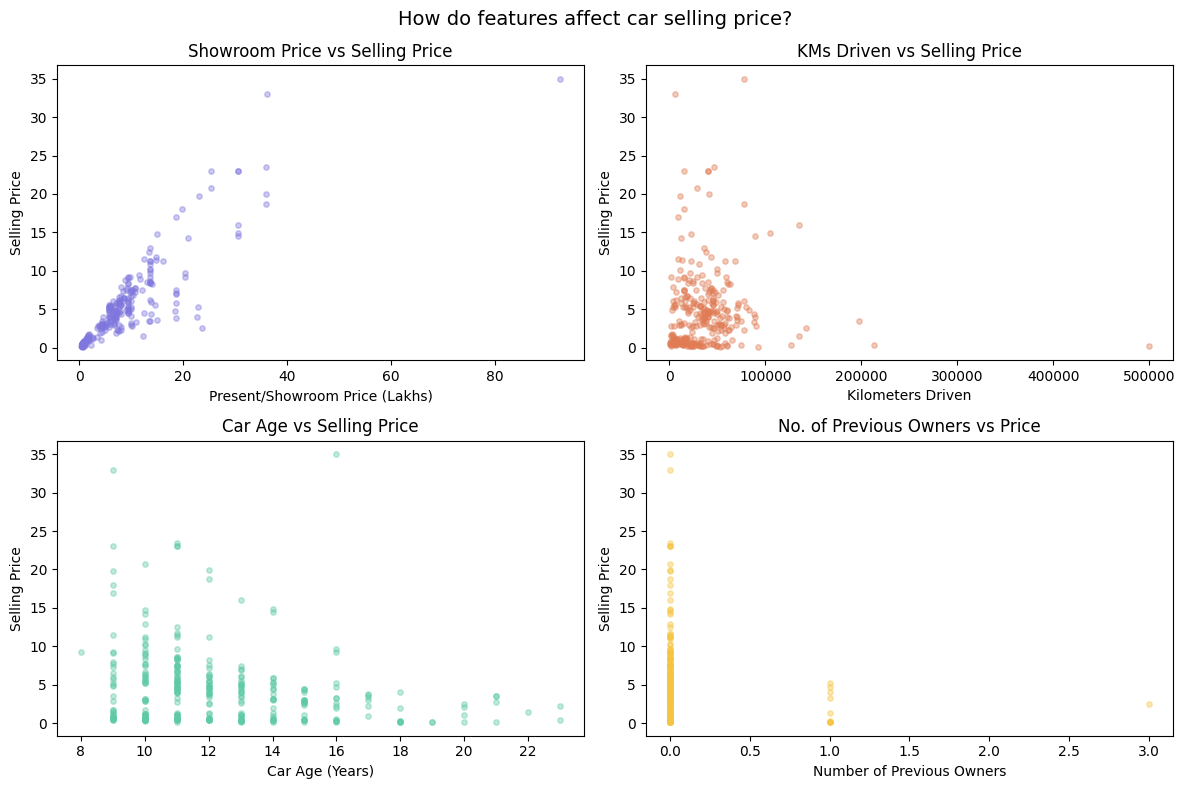

In [11]:
# ── CELL 7: Chart 2 — Key Features vs Price ───────────
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Showroom price vs selling price
axes[0,0].scatter(df['Present_Price'], df['Selling_Price'],
                  alpha=0.4, color='#7F77DD', s=15)
axes[0,0].set_title('Showroom Price vs Selling Price')
axes[0,0].set_xlabel('Present/Showroom Price (Lakhs)')
axes[0,0].set_ylabel('Selling Price')

# KM driven vs selling price
axes[0,1].scatter(df['Kms_Driven'], df['Selling_Price'],
                  alpha=0.4, color='#E07B54', s=15)
axes[0,1].set_title('KMs Driven vs Selling Price')
axes[0,1].set_xlabel('Kilometers Driven')
axes[0,1].set_ylabel('Selling Price')

# Car age vs selling price
axes[1,0].scatter(df['Car_Age'], df['Selling_Price'],
                  alpha=0.4, color='#5DCAA5', s=15)
axes[1,0].set_title('Car Age vs Selling Price')
axes[1,0].set_xlabel('Car Age (Years)')
axes[1,0].set_ylabel('Selling Price')

# Owners vs selling price
axes[1,1].scatter(df['Owner'], df['Selling_Price'],
                  alpha=0.4, color='#F5C542', s=15)
axes[1,1].set_title('No. of Previous Owners vs Price')
axes[1,1].set_xlabel('Number of Previous Owners')
axes[1,1].set_ylabel('Selling Price')

plt.suptitle('How do features affect car selling price?', fontsize=14)
plt.tight_layout()
plt.show()

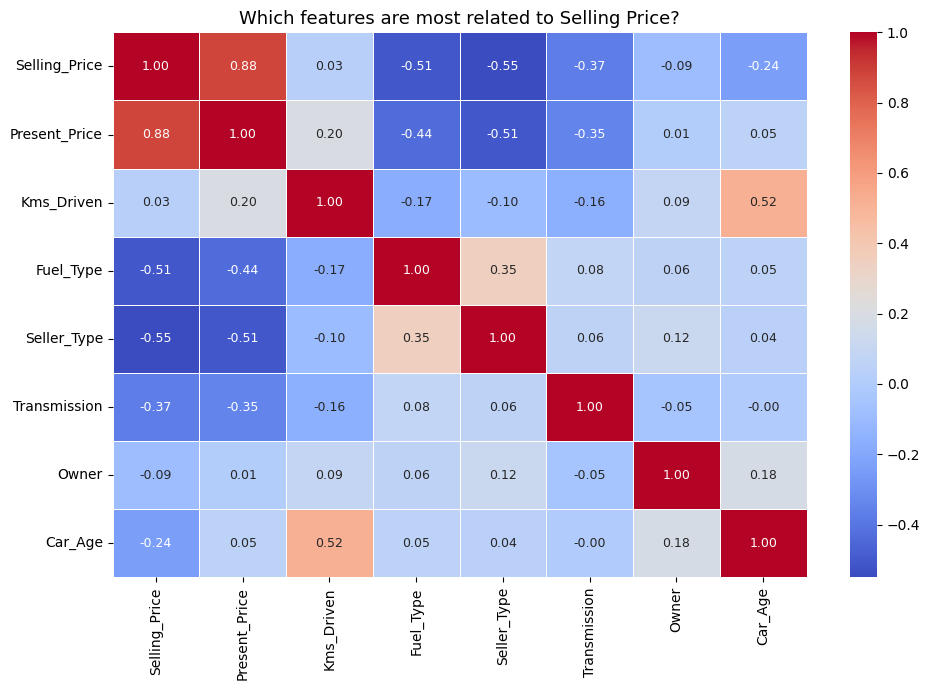

Present_Price will have highest correlation with Selling_Price
Car_Age will have negative correlation — older car = lower price


In [12]:
# ── CELL 8: Chart 3 — Correlation Heatmap ─────────────
plt.figure(figsize=(10, 7))
sns.heatmap(df.corr().round(2),
            annot=True, cmap='coolwarm',
            fmt='.2f', linewidths=0.5,
            annot_kws={'size': 9})
plt.title('Which features are most related to Selling Price?', fontsize=13)
plt.tight_layout()
plt.show()
print('Present_Price will have highest correlation with Selling_Price')
print('Car_Age will have negative correlation — older car = lower price')

In [13]:
# ── CELL 9 FIXED: Prepare Features & Target ───────────
X = df.drop('Selling_Price', axis=1)
y = df['Selling_Price']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f'Features used     : {list(X.columns)}')
print(f'Training samples  : {len(X_train)}')
print(f'Testing  samples  : {len(X_test)}')
print('✅ Data ready for training!')

Features used     : ['Present_Price', 'Kms_Driven', 'Fuel_Type', 'Seller_Type', 'Transmission', 'Owner', 'Car_Age']
Training samples  : 240
Testing  samples  : 61
✅ Data ready for training!


In [14]:
# ── CELL 10: Model 1 — Linear Regression ──────────────
lr = LinearRegression()
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)

lr_mse = mean_squared_error(y_test, lr_pred)
lr_r2  = r2_score(y_test, lr_pred)
lr_rmse = np.sqrt(lr_mse)

print('── Linear Regression Results ──')
print(f'R² Score : {lr_r2:.2f}  (1.0 = perfect)')
print(f'MSE      : {lr_mse:.2f}')
print(f'RMSE     : {lr_rmse:.2f} lakh  ← avg error in price')

── Linear Regression Results ──
R² Score : 0.85  (1.0 = perfect)
MSE      : 3.53
RMSE     : 1.88 lakh  ← avg error in price


In [15]:
# ── CELL 11: Model 2 — Random Forest ──────────────────
# Smarter model — 100 trees voting together!
rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

rf_mse  = mean_squared_error(y_test, rf_pred)
rf_r2   = r2_score(y_test, rf_pred)
rf_rmse = np.sqrt(rf_mse)

print('── Random Forest Results ──')
print(f'R² Score : {rf_r2:.2f}  ← should be better!')
print(f'MSE      : {rf_mse:.2f}')
print(f'RMSE     : {rf_rmse:.2f} lakh  ← avg error in price')
print()
print('── Model Comparison ──')
print(f'Linear Regression R² : {lr_r2:.2f}')
print(f'Random Forest     R² : {rf_r2:.2f}  ← winner! 🏆')

── Random Forest Results ──
R² Score : 0.96  ← should be better!
MSE      : 0.92
RMSE     : 0.96 lakh  ← avg error in price

── Model Comparison ──
Linear Regression R² : 0.85
Random Forest     R² : 0.96  ← winner! 🏆


In [16]:
# ── CELL 11: Model 2 — Random Forest ──────────────────
# Smarter model — 100 trees voting together!
rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

rf_mse  = mean_squared_error(y_test, rf_pred)
rf_r2   = r2_score(y_test, rf_pred)
rf_rmse = np.sqrt(rf_mse)

print('── Random Forest Results ──')
print(f'R² Score : {rf_r2:.2f}  ← should be better!')
print(f'MSE      : {rf_mse:.2f}')
print(f'RMSE     : {rf_rmse:.2f} lakh  ← avg error in price')
print()
print('── Model Comparison ──')
print(f'Linear Regression R² : {lr_r2:.2f}')
print(f'Random Forest     R² : {rf_r2:.2f}  ← winner! 🏆')

── Random Forest Results ──
R² Score : 0.96  ← should be better!
MSE      : 0.92
RMSE     : 0.96 lakh  ← avg error in price

── Model Comparison ──
Linear Regression R² : 0.85
Random Forest     R² : 0.96  ← winner! 🏆


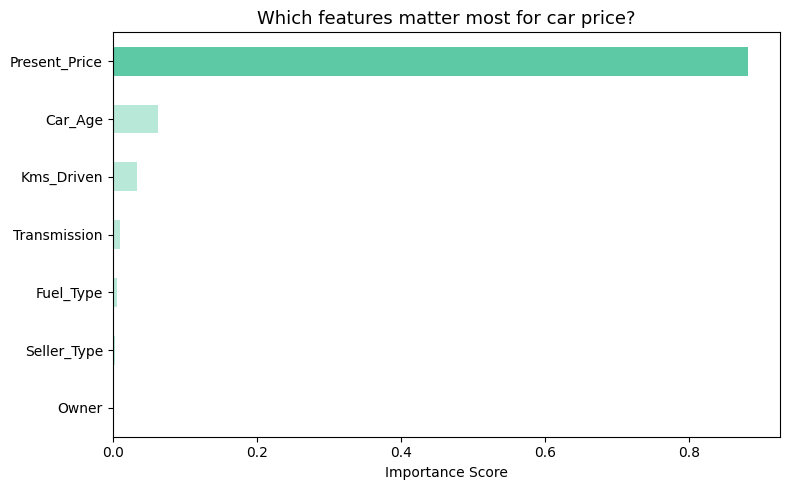

Top 3 most important features:
  1. Present_Price : 0.883
  2. Car_Age : 0.063
  3. Kms_Driven : 0.033


In [17]:
# ── CELL 13: Feature Importance ───────────────────────
importances = pd.Series(
    rf.feature_importances_,
    index=X.columns
).sort_values(ascending=True)

plt.figure(figsize=(8, 5))
colors = ['#5DCAA5' if v > 0.1 else '#B8E8D8' for v in importances]
importances.plot(kind='barh', color=colors)
plt.title('Which features matter most for car price?', fontsize=13)
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

print('Top 3 most important features:')
for i, (feat, val) in enumerate(
    importances.sort_values(ascending=False).head(3).items(), 1
):
    print(f'  {i}. {feat} : {val:.3f}')

In [18]:
# ── CELL 14 FIXED: Predict Price for a NEW Car ────────
new_car = pd.DataFrame([{
    'Present_Price': 6.5,    # showroom price in lakhs
    'Kms_Driven'  : 45000,   # km driven
    'Fuel_Type'   : 1,       # 0=CNG, 1=Diesel, 2=Petrol
    'Seller_Type' : 0,       # 0=Dealer, 1=Individual
    'Transmission': 0,       # 0=Manual, 1=Automatic
    'Owner'       : 0,       # number of previous owners
    'Car_Age'     : 5        # how old is the car
}])

predicted_price = rf.predict(new_car)[0]
print('── Predict Price for Your Car ──')
print(f'Showroom Price : ₹6.5 lakh')
print(f'KMs Driven     : 45,000')
print(f'Car Age        : 5 years')
print(f'Fuel Type      : Diesel')
print(f'Transmission   : Manual')
print()
print(f'🚗 Predicted Selling Price: ₹{predicted_price:.2f} lakh')

── Predict Price for Your Car ──
Showroom Price : ₹6.5 lakh
KMs Driven     : 45,000
Car Age        : 5 years
Fuel Type      : Diesel
Transmission   : Manual

🚗 Predicted Selling Price: ₹4.82 lakh


In [20]:
# ── CELL 15: Final Summary ────────────────────────────
print('=' * 48)
print('   CAR SELLING PRICE PREDICTION')
print('   ShadowFox AIML Internship — Intermediate Task')
print('=' * 48)
print(f'  Dataset       : car data.csv')
print(f'  Total cars    : {len(df)}')
print(f'  Features used : {X.shape[1]}')
print()
print(f'  Model 1 — Linear Regression')
print(f'    R² Score : {lr_r2:.2f}')
print(f'    RMSE     : ₹{lr_rmse:.2f} lakh')
print()
print(f'  Model 2 — Random Forest ✅ Best Model')
print(f'    R² Score : {rf_r2:.2f}')
print(f'    RMSE     : ₹{rf_rmse:.2f} lakh')
print()
top_feat = importances.sort_values(ascending=False).index[0]
print(f'  Top Feature   : {top_feat}')
print(f'  Conclusion    : Random Forest is significantly')
print(f'                  better than Linear Regression')
print('=' * 48)

   CAR SELLING PRICE PREDICTION
   ShadowFox AIML Internship — Intermediate Task
  Dataset       : car data.csv
  Total cars    : 301
  Features used : 7

  Model 1 — Linear Regression
    R² Score : 0.85
    RMSE     : ₹1.88 lakh

  Model 2 — Random Forest ✅ Best Model
    R² Score : 0.96
    RMSE     : ₹0.96 lakh

  Top Feature   : Present_Price
  Conclusion    : Random Forest is significantly
                  better than Linear Regression
